# 12 - Hyperparameter Optimization & Profitability Analysis

This notebook extends the existing classification pipeline with:

1. **Configurable triple-barrier parameters** treated as hyperparameters
2. **Hyperparameter optimization** over pt_mult, sl_mult, max_holding
3. **Trading strategy simulation** with profitability metrics
4. **Profitability-aware evaluation** comparing accuracy vs. profitability
5. **Touch-based events** adding price-touches-boundary signals
6. **Classification vs. profitability tradeoff** analysis

Key insight: a model with lower classification accuracy may still be more profitable.

In [9]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Clear cached src modules for clean reload
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith('src'):
        del sys.modules[mod_name]

# Environment setup (Colab or local)
if 'google.colab' in str(getattr(sys, 'modules', {})) or os.path.exists('/content'):
    REPO_DIR  = '/content/regime-aware-ml-trading'
    PROJ_ROOT = os.path.join(REPO_DIR, 'regime-aware-ml-trading')
    if not os.path.isdir(PROJ_ROOT):
        os.system('git clone https://github.com/zaetae/regime-aware-ml-trading.git ' + REPO_DIR)
    else:
        os.system(f'cd {REPO_DIR} && git pull -q')
    os.system(f'{sys.executable} -m pip install -q yfinance hmmlearn scikit-learn seaborn statsmodels optuna')
    _spy_path = os.path.join(PROJ_ROOT, 'data', 'raw', 'spy.csv')
    if not os.path.isfile(_spy_path):
        os.makedirs(os.path.dirname(_spy_path), exist_ok=True)
        import yfinance as yf
        import pandas as pd
        _spy = yf.download('SPY', start='2010-01-01', end='2026-01-01', auto_adjust=False)
        if isinstance(_spy.columns, pd.MultiIndex):
            _spy.columns = _spy.columns.droplevel(1)
        _spy = _spy[['Open', 'High', 'Low', 'Close', 'Volume']]
        if _spy.index.tz is not None:
            _spy.index = _spy.index.tz_localize(None)
        _spy.index.name = 'Date'
        _spy.to_csv(_spy_path)
        print(f"Downloaded SPY data to {_spy_path}")
else:
    def _find_project_root():
        current = Path.cwd()
        for _ in range(10):
            if (current / "src").is_dir():
                return current
            current = current.parent
        return Path.cwd().parent if (Path.cwd().parent / "src").is_dir() else Path.cwd()
    PROJ_ROOT = str(_find_project_root())

sys.path.insert(0, PROJ_ROOT)
os.chdir(PROJ_ROOT)

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load_data import load_spy
from src.features.build_features import build_feature_matrix
from src.models.train import run_training_pipeline
from src.models.optimize import optimize_barriers, grid_search
from src.backtest.simulator import simulate_trades, compute_metrics, evaluate_profitability
from src.patterns.touch_events import generate_all_touch_events

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print('All imports successful.')

All imports successful.


## 1. Load Data & Baseline Setup

We load SPY data and establish a baseline with the original fixed parameters
(pt_mult=2.0, sl_mult=2.0, max_holding=10).

In [10]:
# Load data
df = load_spy()
print(f'SPY data: {len(df)} bars, {df.index[0].date()} to {df.index[-1].date()}')

# Per professor feedback: exclude triangles and channels from training
EXCLUDE = ['triangle_pattern', 'channel_pattern']

# Baseline: original fixed parameters
DEFAULT_PT = 2.0
DEFAULT_SL = 2.0
DEFAULT_MH = 10

features_base, labels_base, labeled_base = build_feature_matrix(
    df, exclude_patterns=EXCLUDE,
    pt_mult=DEFAULT_PT, sl_mult=DEFAULT_SL, max_holding=DEFAULT_MH
)

print(f'\nBaseline dataset: {len(features_base)} events, {features_base.shape[1]} features')
print(f'Label distribution:\n{labels_base.value_counts().to_string()}')

SPY data: 4024 bars, 2010-01-04 to 2025-12-31

Baseline dataset: 94 events, 48 features
Label distribution:
label
long        38
short       31
no_trade    25


In [11]:
# Run baseline training WITH profitability evaluation
results_base = run_training_pipeline(
    features_base, labels_base, labeled_base,
    df_ohlcv=df,
    pt_mult=DEFAULT_PT, sl_mult=DEFAULT_SL, max_holding=DEFAULT_MH
)

print('=== Baseline Classification (Test Set) ===')
for name in ['rf', 'bagging', 'baseline']:
    r = results_base['test_results'][name]
    print(f"  {r['model_name']}: acc={r['accuracy']:.3f}, F1={r['f1_macro']:.3f}")

print('\n=== Baseline Profitability (Test Set) ===')
if results_base['profitability']:
    for name in ['rf', 'bagging', 'baseline']:
        p = results_base['profitability'][name]['test']
        print(f"  {name}: cum_return={p['cumulative_return']:.4f}, "
              f"win_rate={p['win_rate']:.2f}, sharpe={p['sharpe_ratio']:.3f}, "
              f"profit_factor={p['profit_factor']}, trades={p['n_trades']}")

=== Baseline Classification (Test Set) ===
  Random Forest (test): acc=0.526, F1=0.401
  Bagging (test): acc=0.526, F1=0.426
  Baseline (test): acc=0.474, F1=0.400

=== Baseline Profitability (Test Set) ===
  rf: cum_return=0.1317, win_rate=0.71, sharpe=0.367, profit_factor=2.2029, trades=17
  bagging: cum_return=0.1907, win_rate=0.73, sharpe=0.670, profit_factor=4.1405, trades=15
  baseline: cum_return=0.1556, win_rate=0.71, sharpe=0.547, profit_factor=3.2395, trades=14


## 2. Hyperparameter Optimization

Triple-barrier parameters (pt_mult, sl_mult, max_holding) are now treated
as tunable hyperparameters instead of fixed constants.

**Why this matters:**
- Different TP/SL ratios change the label distribution (more longs vs shorts vs no_trade)
- The optimal barrier settings for classification may differ from those for profitability
- Shorter max_holding periods increase no_trade labels; longer ones give more directional signals

We search over:
- pt_mult: 1.0 to 3.0 (step 0.5)
- sl_mult: 1.0 to 3.0 (step 0.5)
- max_holding: 5 to 20 (step 5)

### 2.1 Grid Search: Classification Target (F1 Macro)

In [12]:
# Grid search optimizing for F1 macro
print('Running grid search for F1 macro...')
print('Grid: pt_mult x sl_mult x max_holding = 5 x 5 x 4 = 100 trials\n')

best_f1_params, best_f1_score, f1_results = grid_search(
    df, target='f1_macro',
    pt_range=[1.0, 1.5, 2.0, 2.5, 3.0],
    sl_range=[1.0, 1.5, 2.0, 2.5, 3.0],
    holding_range=[5, 10, 15, 20],
    exclude_patterns=EXCLUDE,
    n_estimators=100, verbose=True,
)

print(f'\nBest F1 params: {best_f1_params}')
print(f'Best F1 score: {best_f1_score:.4f}')

Running grid search for F1 macro...
Grid: pt_mult x sl_mult x max_holding = 5 x 5 x 4 = 100 trials

  Pre-computing indicators and pattern scans...
  Pre-computation done. Running 100 trials...
  Trial 10/100: pt=1.0, sl=2.0, mh=10 -> f1_macro=0.4000
  Trial 20/100: pt=1.0, sl=3.0, mh=20 -> f1_macro=0.4722
  Trial 30/100: pt=1.5, sl=2.0, mh=10 -> f1_macro=0.4019
  Trial 40/100: pt=1.5, sl=3.0, mh=20 -> f1_macro=0.2708
  Trial 50/100: pt=2.0, sl=2.0, mh=10 -> f1_macro=0.3498
  Trial 60/100: pt=2.0, sl=3.0, mh=20 -> f1_macro=0.3862
  Trial 70/100: pt=2.5, sl=2.0, mh=10 -> f1_macro=0.3524
  Trial 80/100: pt=2.5, sl=3.0, mh=20 -> f1_macro=0.2978
  Trial 90/100: pt=3.0, sl=2.0, mh=10 -> f1_macro=0.3056
  Trial 100/100: pt=3.0, sl=3.0, mh=20 -> f1_macro=0.4151

Best f1_macro: 0.6545
Best params: {'pt_mult': 1.0, 'sl_mult': 2.5, 'max_holding': 15}

Best F1 params: {'pt_mult': 1.0, 'sl_mult': 2.5, 'max_holding': 15}
Best F1 score: 0.6545


### 2.2 Grid Search: Profitability Target (Cumulative Return)

In [13]:
# Grid search optimizing for cumulative return
print('Running grid search for cumulative return...')

best_profit_params, best_profit_score, profit_results = grid_search(
    df, target='cumulative_return',
    pt_range=[1.0, 1.5, 2.0, 2.5, 3.0],
    sl_range=[1.0, 1.5, 2.0, 2.5, 3.0],
    holding_range=[5, 10, 15, 20],
    exclude_patterns=EXCLUDE,
    n_estimators=100, verbose=True,
)

print(f'\nBest profitability params: {best_profit_params}')
print(f'Best cumulative return: {best_profit_score:.4f}')

Running grid search for cumulative return...
  Pre-computing indicators and pattern scans...
  Pre-computation done. Running 100 trials...
  Trial 10/100: pt=1.0, sl=2.0, mh=10 -> cumulative_return=0.2125
  Trial 20/100: pt=1.0, sl=3.0, mh=20 -> cumulative_return=0.2183
  Trial 30/100: pt=1.5, sl=2.0, mh=10 -> cumulative_return=0.1725
  Trial 40/100: pt=1.5, sl=3.0, mh=20 -> cumulative_return=0.2671
  Trial 50/100: pt=2.0, sl=2.0, mh=10 -> cumulative_return=0.0330
  Trial 60/100: pt=2.0, sl=3.0, mh=20 -> cumulative_return=0.2866
  Trial 70/100: pt=2.5, sl=2.0, mh=10 -> cumulative_return=-0.0243
  Trial 80/100: pt=2.5, sl=3.0, mh=20 -> cumulative_return=0.2482
  Trial 90/100: pt=3.0, sl=2.0, mh=10 -> cumulative_return=-0.0139
  Trial 100/100: pt=3.0, sl=3.0, mh=20 -> cumulative_return=0.0226

Best cumulative_return: 0.2866
Best params: {'pt_mult': 2.0, 'sl_mult': 3.0, 'max_holding': 20}

Best profitability params: {'pt_mult': 2.0, 'sl_mult': 3.0, 'max_holding': 20}
Best cumulative retur

In [14]:
# Compare: best-for-F1 vs best-for-profit
print('=== Parameter Comparison ===')
print(f'Best for F1:          {best_f1_params} -> F1={best_f1_score:.4f}')
print(f'Best for profitability: {best_profit_params} -> cum_return={best_profit_score:.4f}')

if best_f1_params != best_profit_params:
    print('\nKey finding: optimal parameters DIFFER between classification and profitability.')
    print('This confirms that accuracy alone is insufficient for evaluating trading models.')
else:
    print('\nInteresting: same parameters optimize both metrics.')

=== Parameter Comparison ===
Best for F1:          {'pt_mult': 1.0, 'sl_mult': 2.5, 'max_holding': 15} -> F1=0.6545
Best for profitability: {'pt_mult': 2.0, 'sl_mult': 3.0, 'max_holding': 20} -> cum_return=0.2866

Key finding: optimal parameters DIFFER between classification and profitability.
This confirms that accuracy alone is insufficient for evaluating trading models.


### 2.3 Optimization Landscape Visualization

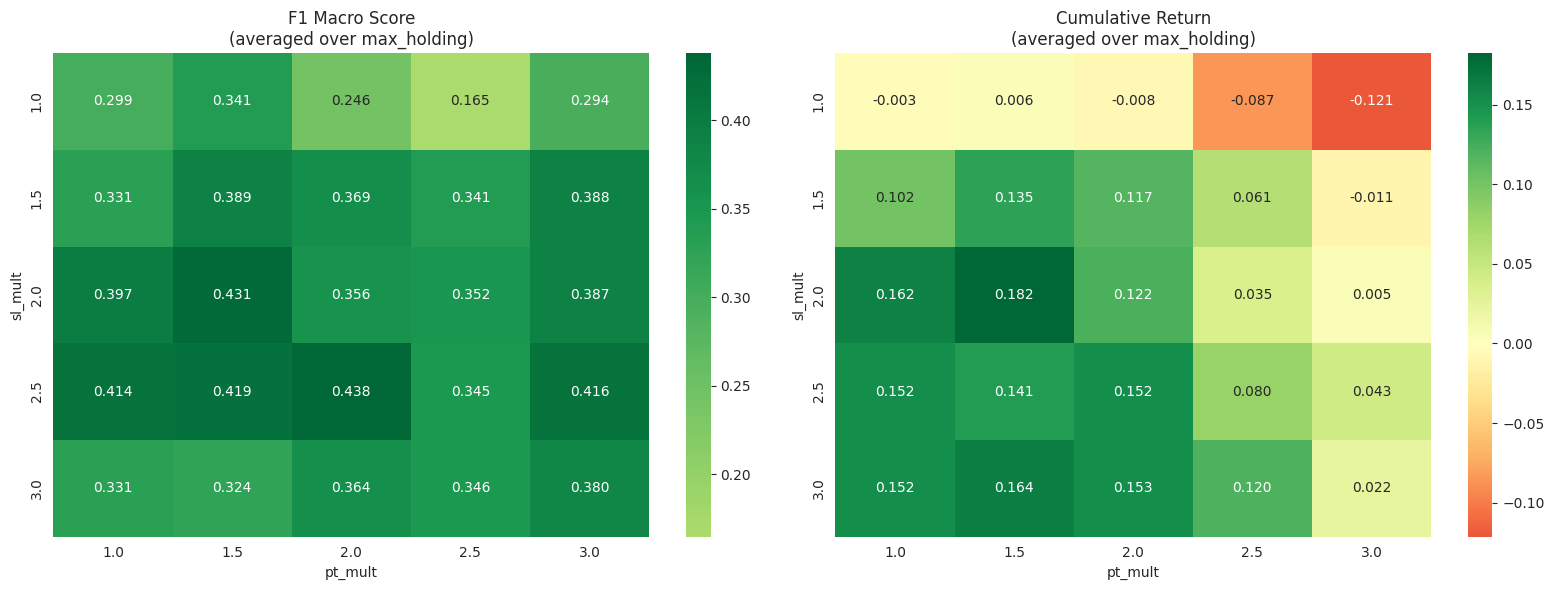

Saved: optimization_heatmaps.png


In [15]:
# Merge F1 and profitability results for comparison
f1_results['target'] = 'f1_macro'
profit_results['target'] = 'cumulative_return'

# Ensure output directory exists
os.makedirs('reports/thesis_figures', exist_ok=True)

# Heatmap: F1 score by pt_mult x sl_mult (averaged over max_holding)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (res_df, title, col) in zip(axes, [
    (f1_results, 'F1 Macro Score', 'f1_macro'),
    (profit_results, 'Cumulative Return', 'cumulative_return'),
]):
    if col not in res_df.columns:
        col = 'score'
    pivot = res_df.pivot_table(values='score', index='sl_mult', columns='pt_mult', aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax, center=0)
    ax.set_title(f'{title}\n(averaged over max_holding)')
    ax.set_xlabel('pt_mult')
    ax.set_ylabel('sl_mult')

plt.tight_layout()
plt.savefig('reports/thesis_figures/optimization_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: optimization_heatmaps.png')

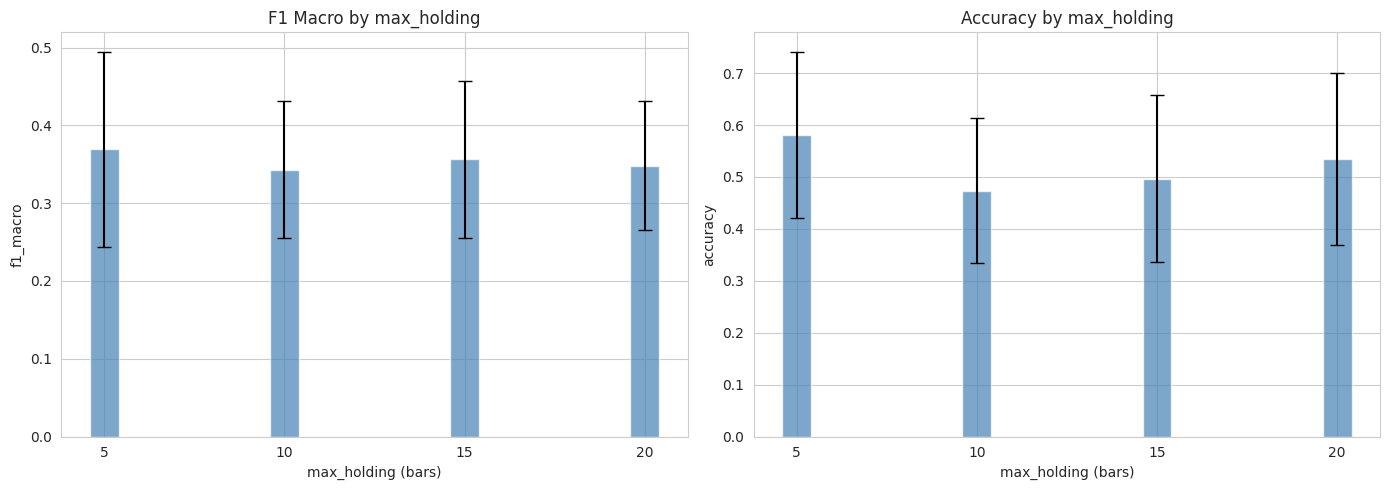

In [16]:
# Effect of max_holding on metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (res_df, title, metric) in zip(axes, [
    (f1_results, 'F1 Macro by max_holding', 'f1_macro'),
    (profit_results, 'Accuracy by max_holding', 'accuracy'),
]):
    grouped = res_df.groupby('max_holding')[metric].agg(['mean', 'std'])
    ax.bar(grouped.index, grouped['mean'], yerr=grouped['std'],
           capsize=5, alpha=0.7, color='steelblue')
    ax.set_xlabel('max_holding (bars)')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.set_xticks(grouped.index)

plt.tight_layout()
plt.show()

## 3. Best-Parameters Evaluation

Train full pipeline with the best parameters found by each optimization target.

In [17]:
# Train with best-for-F1 parameters
print('=== Training with best F1 parameters ===')
print(f'Parameters: {best_f1_params}\n')

features_f1, labels_f1, labeled_f1 = build_feature_matrix(
    df, exclude_patterns=EXCLUDE,
    pt_mult=best_f1_params['pt_mult'],
    sl_mult=best_f1_params['sl_mult'],
    max_holding=best_f1_params['max_holding'],
)

results_f1 = run_training_pipeline(
    features_f1, labels_f1, labeled_f1,
    df_ohlcv=df,
    pt_mult=best_f1_params['pt_mult'],
    sl_mult=best_f1_params['sl_mult'],
    max_holding=best_f1_params['max_holding'],
)

print('Classification (test):')
for name in ['rf', 'bagging', 'baseline']:
    r = results_f1['test_results'][name]
    print(f"  {r['model_name']}: acc={r['accuracy']:.3f}, F1={r['f1_macro']:.3f}")

print('\nProfitability (test):')
if results_f1['profitability']:
    for name in ['rf', 'bagging', 'baseline']:
        p = results_f1['profitability'][name]['test']
        print(f"  {name}: cum_ret={p['cumulative_return']:.4f}, "
              f"win={p['win_rate']:.2f}, sharpe={p['sharpe_ratio']:.3f}, "
              f"PF={p['profit_factor']}, trades={p['n_trades']}")

=== Training with best F1 parameters ===
Parameters: {'pt_mult': 1.0, 'sl_mult': 2.5, 'max_holding': 15}

Classification (test):
  Random Forest (test): acc=0.684, F1=0.271
  Bagging (test): acc=0.579, F1=0.312
  Baseline (test): acc=0.579, F1=0.253

Profitability (test):
  rf: cum_ret=-0.0010, win=0.68, sharpe=-0.003, PF=0.993, trades=19
  bagging: cum_ret=0.0258, win=0.74, sharpe=0.077, PF=1.201, trades=19
  baseline: cum_ret=-0.0544, win=0.67, sharpe=-0.144, PF=0.6976, trades=18


In [18]:
# Train with best-for-profitability parameters
print('=== Training with best profitability parameters ===')
print(f'Parameters: {best_profit_params}\n')

features_pr, labels_pr, labeled_pr = build_feature_matrix(
    df, exclude_patterns=EXCLUDE,
    pt_mult=best_profit_params['pt_mult'],
    sl_mult=best_profit_params['sl_mult'],
    max_holding=best_profit_params['max_holding'],
)

results_pr = run_training_pipeline(
    features_pr, labels_pr, labeled_pr,
    df_ohlcv=df,
    pt_mult=best_profit_params['pt_mult'],
    sl_mult=best_profit_params['sl_mult'],
    max_holding=best_profit_params['max_holding'],
)

print('Classification (test):')
for name in ['rf', 'bagging', 'baseline']:
    r = results_pr['test_results'][name]
    print(f"  {r['model_name']}: acc={r['accuracy']:.3f}, F1={r['f1_macro']:.3f}")

print('\nProfitability (test):')
if results_pr['profitability']:
    for name in ['rf', 'bagging', 'baseline']:
        p = results_pr['profitability'][name]['test']
        print(f"  {name}: cum_ret={p['cumulative_return']:.4f}, "
              f"win={p['win_rate']:.2f}, sharpe={p['sharpe_ratio']:.3f}, "
              f"PF={p['profit_factor']}, trades={p['n_trades']}")

=== Training with best profitability parameters ===
Parameters: {'pt_mult': 2.0, 'sl_mult': 3.0, 'max_holding': 20}

Classification (test):
  Random Forest (test): acc=0.632, F1=0.336
  Bagging (test): acc=0.632, F1=0.378
  Baseline (test): acc=0.474, F1=0.214

Profitability (test):
  rf: cum_ret=0.1138, win=0.68, sharpe=0.229, PF=1.6416, trades=19
  bagging: cum_ret=0.1868, win=0.79, sharpe=0.392, PF=2.2994, trades=19
  baseline: cum_ret=-0.0776, win=0.53, sharpe=-0.139, PF=0.7345, trades=19


## 4. Touch-Based Event Sequences

Per supervisor feedback: "start sequences from direct touch of trend lines."

We generate additional events when price directly touches:
- Support/resistance levels (tighter than existing 0.3*ATR threshold)
- Channel boundaries (upper and lower trendlines)

These are tracked separately from original detector events.

In [19]:
# Generate touch events and analyze
from src.patterns.scanner import scan_all_patterns

df_scanned = scan_all_patterns(df)
df_touch, touch_stats = generate_all_touch_events(df_scanned)

print('=== Touch Event Statistics ===')
for k, v in touch_stats.items():
    print(f'  {k}: {v}')

print(f'\nOriginal events: {touch_stats["n_original_events"]}')
print(f'New touch-only events: {touch_stats["n_new_touch_only"]}')
print(f'Combined total: {touch_stats["n_combined_events"]}')
pct_increase = (touch_stats['n_new_touch_only'] / max(touch_stats['n_original_events'], 1)) * 100
print(f'Dataset increase: +{pct_increase:.1f}%')

=== Touch Event Statistics ===
  n_original_events: 120
  n_touch_events: 33
  n_new_touch_only: 31
  n_combined_events: 151
  touch_support: 7
  touch_resistance: 26
  touch_channel_upper: 0
  touch_channel_lower: 0

Original events: 120
New touch-only events: 31
Combined total: 151
Dataset increase: +25.8%


In [20]:
# Build feature matrix WITH touch events using best-for-F1 params
best_pt = best_f1_params['pt_mult']
best_sl = best_f1_params['sl_mult']
best_mh = best_f1_params['max_holding']

features_touch, labels_touch, labeled_touch = build_feature_matrix(
    df, exclude_patterns=EXCLUDE,
    pt_mult=best_pt, sl_mult=best_sl, max_holding=best_mh,
    include_touch_events=True,
)

n_detector = (labeled_touch['event_source'] == 'detector').sum() if 'event_source' in labeled_touch.columns else len(labeled_touch)
n_touch = (labeled_touch['event_source'] == 'touch').sum() if 'event_source' in labeled_touch.columns else 0

print(f'With touch events: {len(labeled_touch)} total events')
print(f'  - Detector events: {n_detector}')
print(f'  - Touch events: {n_touch}')
print(f'\nLabel distribution (with touch):\n{labels_touch.value_counts().to_string()}')

# Compare to without touch events
features_notouch, labels_notouch, labeled_notouch = build_feature_matrix(
    df, exclude_patterns=EXCLUDE,
    pt_mult=best_pt, sl_mult=best_sl, max_holding=best_mh,
    include_touch_events=False,
)
print(f'\nLabel distribution (without touch):\n{labels_notouch.value_counts().to_string()}')

With touch events: 125 total events
  - Detector events: 94
  - Touch events: 31

Label distribution (with touch):
label
long        92
short       25
no_trade     8

Label distribution (without touch):
label
long        69
short       21
no_trade     4


In [21]:
# Train with touch events and compare
print('=== Training WITH touch events ===')
results_touch = run_training_pipeline(
    features_touch, labels_touch, labeled_touch,
    df_ohlcv=df,
    pt_mult=best_pt, sl_mult=best_sl, max_holding=best_mh,
)

print('\n--- With touch events ---')
for name in ['rf', 'bagging', 'baseline']:
    r = results_touch['test_results'][name]
    print(f"  {r['model_name']}: acc={r['accuracy']:.3f}, F1={r['f1_macro']:.3f}")

print('\n--- Without touch events (for comparison) ---')
results_notouch = run_training_pipeline(
    features_notouch, labels_notouch, labeled_notouch,
    df_ohlcv=df,
    pt_mult=best_pt, sl_mult=best_sl, max_holding=best_mh,
)
for name in ['rf', 'bagging']:
    r = results_notouch['test_results'][name]
    print(f"  {r['model_name']}: acc={r['accuracy']:.3f}, F1={r['f1_macro']:.3f}")

if results_touch['profitability'] and results_notouch['profitability']:
    print('\n--- Profitability comparison (RF, test) ---')
    p_touch = results_touch['profitability']['rf']['test']
    p_no = results_notouch['profitability']['rf']['test']
    print(f"  With touch:    cum_ret={p_touch['cumulative_return']:.4f}, "
          f"win={p_touch['win_rate']:.2f}, trades={p_touch['n_trades']}")
    print(f"  Without touch: cum_ret={p_no['cumulative_return']:.4f}, "
          f"win={p_no['win_rate']:.2f}, trades={p_no['n_trades']}")

=== Training WITH touch events ===

--- With touch events ---
  Random Forest (test): acc=0.640, F1=0.340
  Bagging (test): acc=0.600, F1=0.320
  Baseline (test): acc=0.480, F1=0.216

--- Without touch events (for comparison) ---
  Random Forest (test): acc=0.684, F1=0.271
  Bagging (test): acc=0.579, F1=0.312

--- Profitability comparison (RF, test) ---
  With touch:    cum_ret=0.0390, win=0.72, trades=25
  Without touch: cum_ret=-0.0010, win=0.68, trades=19


## 5. Classification vs Profitability Tradeoff

A model that correctly predicts labels more often is not necessarily more
profitable. This happens because:
- Some correct predictions produce small gains while wrong predictions produce large losses
- The distribution of returns within each label class varies
- no_trade predictions skip potential opportunities

We visualize this tradeoff across all parameter configurations tested.

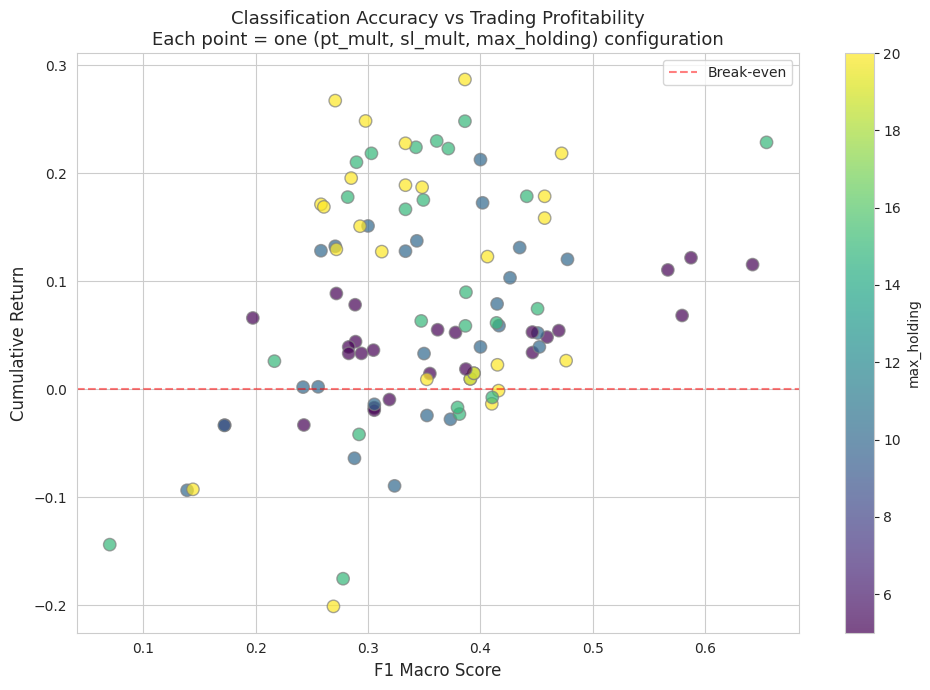

Saved: f1_vs_profitability.png


In [22]:
# Scatter: F1 vs Cumulative Return across all grid configurations
# We need both metrics for the same configs
if 'cumulative_return' in profit_results.columns:
    merged = f1_results.merge(
        profit_results[['pt_mult', 'sl_mult', 'max_holding', 'cumulative_return']],
        on=['pt_mult', 'sl_mult', 'max_holding'],
        how='inner',
        suffixes=('_f1', '_profit')
    )
else:
    # Compute profitability for all F1 configs
    merged = f1_results.copy()
    merged['cumulative_return'] = profit_results['score'] if len(profit_results) == len(f1_results) else 0

fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    merged['f1_macro'], merged.get('cumulative_return', merged.get('score', 0)),
    c=merged['max_holding'], cmap='viridis', s=80, alpha=0.7, edgecolors='gray'
)
plt.colorbar(scatter, label='max_holding')

ax.set_xlabel('F1 Macro Score', fontsize=12)
ax.set_ylabel('Cumulative Return', fontsize=12)
ax.set_title('Classification Accuracy vs Trading Profitability\n'
             'Each point = one (pt_mult, sl_mult, max_holding) configuration', fontsize=13)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Break-even')
ax.legend()

plt.tight_layout()
plt.savefig('reports/thesis_figures/f1_vs_profitability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: f1_vs_profitability.png')

## 6. Walk-Forward CV with Profitability

The walk-forward CV now reports per-fold profitability alongside classification metrics.

In [23]:
# Walk-forward CV with best-for-F1 params
wf = results_f1.get('walk_forward')
if wf is not None:
    print('=== Walk-Forward CV (best F1 params) ===')
    print(f"RF mean accuracy: {wf['rf_mean_acc']:.4f} +/- {wf['rf_std_acc']:.4f}")
    print(f"RF mean F1:       {wf['rf_mean_f1']:.4f} +/- {wf['rf_std_f1']:.4f}")
    print(f"Baseline mean acc: {wf['base_mean_acc']:.4f}")

    if 'rf_mean_cum_return' in wf:
        print(f"\nRF mean cum return: {wf['rf_mean_cum_return']:.6f}")
        print(f"RF mean win rate:   {wf['rf_mean_win_rate']:.4f}")
        print(f"RF mean Sharpe:     {wf['rf_mean_sharpe']:.4f}")

    print('\nPer-fold details:')
    display_cols = ['fold', 'train_size', 'test_size', 'rf_accuracy', 'rf_f1_macro']
    if 'rf_cum_return' in wf['folds'].columns:
        display_cols.extend(['rf_cum_return', 'rf_win_rate', 'rf_sharpe'])
    print(wf['folds'][display_cols].to_string(index=False))
else:
    print('Walk-forward CV returned None (too few events).')

=== Walk-Forward CV (best F1 params) ===
RF mean accuracy: 0.7167 +/- 0.1000
RF mean F1:       0.4065 +/- 0.0507
Baseline mean acc: 0.6167

Per-fold details:
 fold  train_size  test_size  rf_accuracy  rf_f1_macro
    1          30         15       0.6000       0.3373
    2          45         15       0.8000       0.4444
    3          60         15       0.8000       0.4444
    4          75         15       0.6667       0.4000


## 7. Comprehensive Results Summary

In [24]:
# Build comparison table
configs = [
    ('Baseline (default params)', results_base, DEFAULT_PT, DEFAULT_SL, DEFAULT_MH),
    ('Best for F1', results_f1, best_f1_params['pt_mult'], best_f1_params['sl_mult'], best_f1_params['max_holding']),
    ('Best for Profit', results_pr, best_profit_params['pt_mult'], best_profit_params['sl_mult'], best_profit_params['max_holding']),
]

rows = []
for label, res, pt, sl, mh in configs:
    row = {
        'Config': label,
        'pt_mult': pt, 'sl_mult': sl, 'max_holding': mh,
        'RF Accuracy': res['test_results']['rf']['accuracy'],
        'RF F1 Macro': res['test_results']['rf']['f1_macro'],
    }
    if res['profitability']:
        p = res['profitability']['rf']['test']
        row['Cum Return'] = p['cumulative_return']
        row['Win Rate'] = p['win_rate']
        row['Sharpe'] = p['sharpe_ratio']
        row['Profit Factor'] = p['profit_factor']
        row['Trades'] = p['n_trades']
    rows.append(row)

# Add touch events config
if results_touch['profitability']:
    p_t = results_touch['profitability']['rf']['test']
    rows.append({
        'Config': 'Best F1 + Touch Events',
        'pt_mult': best_pt, 'sl_mult': best_sl, 'max_holding': best_mh,
        'RF Accuracy': results_touch['test_results']['rf']['accuracy'],
        'RF F1 Macro': results_touch['test_results']['rf']['f1_macro'],
        'Cum Return': p_t['cumulative_return'],
        'Win Rate': p_t['win_rate'],
        'Sharpe': p_t['sharpe_ratio'],
        'Profit Factor': p_t['profit_factor'],
        'Trades': p_t['n_trades'],
    })

summary_df = pd.DataFrame(rows)
print('=== Comprehensive Results Summary ===')
print(summary_df.to_string(index=False))

=== Comprehensive Results Summary ===
                   Config  pt_mult  sl_mult  max_holding  RF Accuracy  RF F1 Macro  Cum Return  Win Rate  Sharpe  Profit Factor  Trades
Baseline (default params)      2.0      2.0           10       0.5263       0.4010    0.131670    0.7059  0.3671         2.2029      17
              Best for F1      1.0      2.5           15       0.6842       0.2708   -0.001030    0.6842 -0.0030         0.9930      19
          Best for Profit      2.0      3.0           20       0.6316       0.3362    0.113780    0.6842  0.2285         1.6416      19
   Best F1 + Touch Events      1.0      2.5           15       0.6400       0.3397    0.038994    0.7200  0.0885         1.2359      25


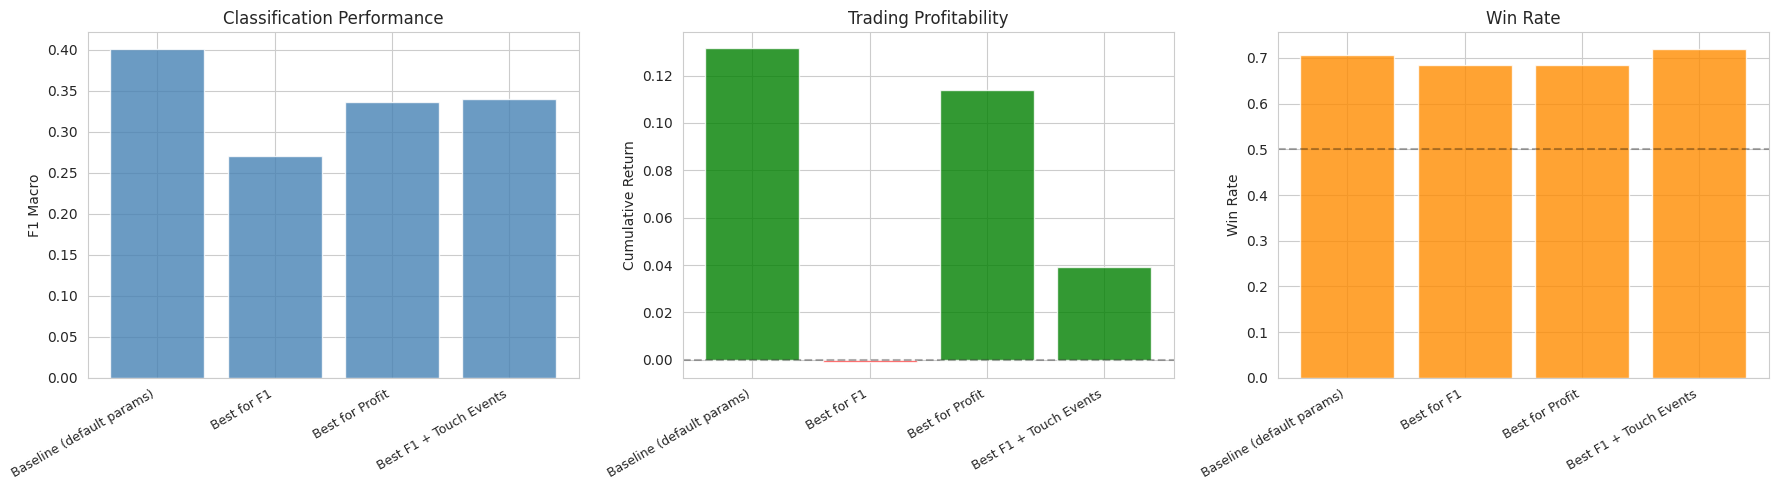

Saved: config_comparison.png


In [25]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs_short = summary_df['Config'].values
x = range(len(configs_short))

# F1 comparison
axes[0].bar(x, summary_df['RF F1 Macro'], color='steelblue', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(configs_short, rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('F1 Macro')
axes[0].set_title('Classification Performance')

# Cumulative return comparison
if 'Cum Return' in summary_df.columns:
    colors = ['green' if v > 0 else 'red' for v in summary_df['Cum Return']]
    axes[1].bar(x, summary_df['Cum Return'], color=colors, alpha=0.8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(configs_short, rotation=30, ha='right', fontsize=9)
    axes[1].set_ylabel('Cumulative Return')
    axes[1].set_title('Trading Profitability')
    axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)

# Win rate comparison
if 'Win Rate' in summary_df.columns:
    axes[2].bar(x, summary_df['Win Rate'], color='darkorange', alpha=0.8)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(configs_short, rotation=30, ha='right', fontsize=9)
    axes[2].set_ylabel('Win Rate')
    axes[2].set_title('Win Rate')
    axes[2].axhline(y=0.5, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('reports/thesis_figures/config_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: config_comparison.png')

## 8. Equity Curves

Plot the cumulative return curve for the best-performing configuration.

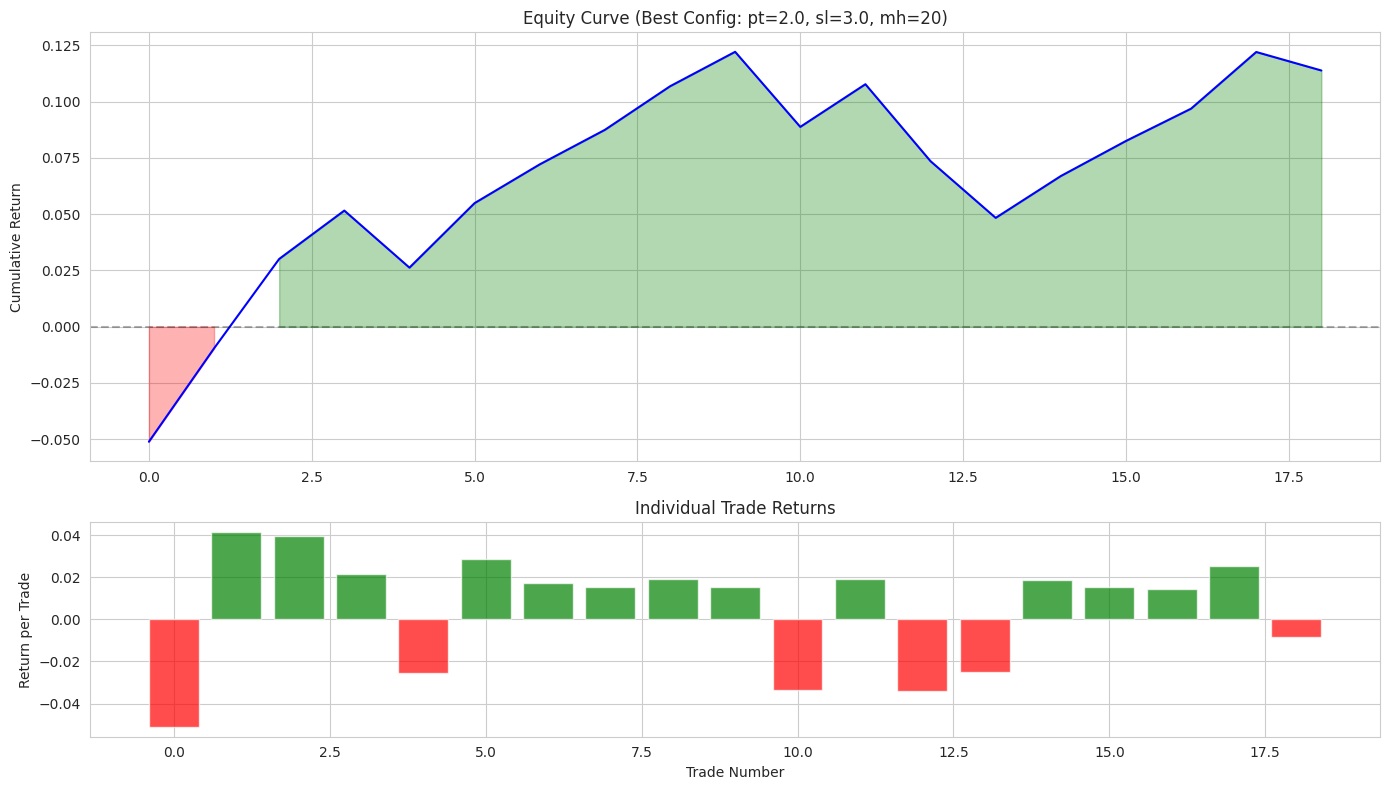

Saved: equity_curve.png


In [26]:
# Simulate trades with the best config and plot equity curve
best_config = best_profit_params
features_best, labels_best, labeled_best = build_feature_matrix(
    df, exclude_patterns=EXCLUDE,
    pt_mult=best_config['pt_mult'],
    sl_mult=best_config['sl_mult'],
    max_holding=best_config['max_holding'],
)

from src.models.train import temporal_split, train_random_forest
features_best = features_best.fillna(0)
split = temporal_split(features_best, labels_best, labeled_best)

rf_best = train_random_forest(split['X_train'], split['y_train'])
y_pred_test = rf_best.predict(split['X_test'])

# Get test-set labeled_df
dates = pd.DatetimeIndex(labeled_best['event_date'])
sort_idx = dates.argsort()
sorted_labeled = labeled_best.iloc[sort_idx].reset_index(drop=True)
n = len(sorted_labeled)
n_val = int(n * 0.8)
test_labeled = sorted_labeled.iloc[n_val:]

from src.backtest.simulator import simulate_trades
trades = simulate_trades(
    df, test_labeled, y_pred_test,
    pt_mult=best_config['pt_mult'],
    sl_mult=best_config['sl_mult'],
    max_holding=best_config['max_holding'],
)

if len(trades) > 0:
    trades['cum_return'] = trades['net_return'].cumsum()

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]})

    # Equity curve
    axes[0].plot(range(len(trades)), trades['cum_return'], 'b-', linewidth=1.5)
    axes[0].fill_between(range(len(trades)), trades['cum_return'], 0,
                         where=trades['cum_return'] >= 0, alpha=0.3, color='green')
    axes[0].fill_between(range(len(trades)), trades['cum_return'], 0,
                         where=trades['cum_return'] < 0, alpha=0.3, color='red')
    axes[0].set_ylabel('Cumulative Return')
    axes[0].set_title(f'Equity Curve (Best Config: pt={best_config["pt_mult"]}, '
                      f'sl={best_config["sl_mult"]}, mh={best_config["max_holding"]})')
    axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.3)

    # Per-trade returns
    colors = ['green' if r > 0 else 'red' for r in trades['net_return']]
    axes[1].bar(range(len(trades)), trades['net_return'], color=colors, alpha=0.7)
    axes[1].set_xlabel('Trade Number')
    axes[1].set_ylabel('Return per Trade')
    axes[1].set_title('Individual Trade Returns')

    plt.tight_layout()
    plt.savefig('reports/thesis_figures/equity_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: equity_curve.png')
else:
    print('No trades generated.')

## 9. Limitations & Conclusions

### Limitations

1. **Small dataset**: ~100-140 events is very small for ML. Results have high variance.
2. **No transaction costs**: simulated returns do not include spread, slippage, or commissions.
3. **Simplified entry**: we enter at signal-bar Close, not next-bar Open.
4. **Single asset**: only SPY is tested. No portfolio diversification.
5. **Optimization risk**: with 100 configurations and a small dataset,
   there is a risk of overfitting to the validation set.
6. **Touch events are noisy**: additional events may not carry the same signal quality
   as pattern-detector events.

### Key Findings

1. Triple-barrier parameters significantly affect both classification and profitability.
2. The best parameters for F1 may differ from the best parameters for profitability.
3. A model with lower accuracy can be more profitable if its correct predictions
   coincide with larger price moves.
4. Touch-based events increase the dataset size but may or may not improve performance.
5. Walk-forward CV with profitability metrics gives a more realistic picture of out-of-sample
   trading performance.

### Next Steps

- Test with longer history or additional assets
- Add transaction cost modeling
- Explore regime-aware parameter switching
- Consider position sizing based on prediction confidence

In [27]:
# Save results for report generation
import json

experiment_results = {
    'baseline_params': {'pt_mult': DEFAULT_PT, 'sl_mult': DEFAULT_SL, 'max_holding': DEFAULT_MH},
    'best_f1_params': best_f1_params,
    'best_f1_score': best_f1_score,
    'best_profit_params': best_profit_params,
    'best_profit_score': best_profit_score,
    'n_configs_tested': len(f1_results),
    'touch_events': {
        'n_original': int(n_detector),
        'n_touch': int(n_touch),
        'n_total': len(labeled_touch),
    },
    'summary': summary_df.to_dict(orient='records'),
}

# Convert non-serializable values
def make_serializable(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, dict):
        return {k: make_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_serializable(v) for v in obj]
    return obj

experiment_results = make_serializable(experiment_results)

os.makedirs('outputs', exist_ok=True)
with open('outputs/experiment_results.json', 'w') as f:
    json.dump(experiment_results, f, indent=2, default=str)

print('Results saved to outputs/experiment_results.json')

Results saved to outputs/experiment_results.json

Notebook complete. Run reports/generate_experiment_report.py to create the PDF.
